# Clustering Evaluation

**Topic:** Unsupervised Learning — Evaluation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from tkh_utils import PALETTE


---
## What you'll explore

By the end of this demo you will be able to:

- **Describe** three complementary clustering evaluation metrics: WCSS elbow, gap statistic, and silhouette score
- **Explain** why no single metric gives a definitive answer for the optimal number of clusters
- **Interpret** each metric's chart and combine them with domain knowledge to make a final K choice

> **Tip:** Run all three metrics, look for the K value where at least two of them agree, then ask yourself: does that K make sense for the problem I'm solving?

---
## How we got here

In **[02_kmeans_clustering.ipynb](02_kmeans_clustering.ipynb)**, **[03_gaussian_mixture_models.ipynb](03_gaussian_mixture_models.ipynb)**, **[04_hierarchical_clustering.ipynb](04_hierarchical_clustering.ipynb)**, and **[05_dbscan.ipynb](05_dbscan.ipynb)** you learned four clustering algorithms. Every one of them requires a choice that evaluation must inform: how many clusters? How much density?

In **[statistics/07_descriptive_statistics_in_practice.ipynb](../statistics/07_descriptive_statistics_in_practice.ipynb)** you learned to quantify spread and central tendency — both are central to the evaluation metrics here. In **[ml_concepts/11_the_curse_of_dimensionality.ipynb](../ml_concepts/11_the_curse_of_dimensionality.ipynb)** you saw why distance becomes less meaningful in high dimensions — since silhouette score is built entirely from distances, it inherits that same limitation. In **[statistics/17_hypothesis_testing.ipynb](../statistics/17_hypothesis_testing.ipynb)** you met the idea of a "null" case — the boring, no-effect default you compare your data against. The gap statistic reuses that exact idea to decide whether your clusters are real.

---
## Why this matters for data science

Choosing K is the most consequential decision in clustering. Too few: important sub-groups get merged. Too many: noise becomes "clusters" and results become uninterpretable.

No algorithm can make this decision for you — it requires quantitative evidence (from metrics) combined with qualitative judgment (from domain knowledge). This notebook gives you the quantitative tools. The qualitative judgment is yours.

\
---
## Where it sits on the spectrum

Referencing **[ml_concepts/13_interpretability_vs_complexity.ipynb](../ml_concepts/13_interpretability_vs_complexity.ipynb)**:

This is an evaluation notebook rather than a single algorithm. The metrics themselves sit at the low-complexity, high-utility end of the spectrum. Silhouette score and WCSS are computationally cheap; gap statistic involves running clustering multiple times on reference datasets, making it the most expensive of the three.

**Key insight:** Evaluation metrics are only as interpretable as your understanding of what they measure. This notebook builds that understanding.

\
---
## How it learns

These are evaluation metrics, not learning algorithms. Each measures a different aspect of cluster quality.

**WCSS (Within-Cluster Sum of Squares):** Measures total compactness — how close points are to their centroid. Always decreases as K increases; the "elbow" is a heuristic for where the benefit of adding one more cluster starts to diminish.

**Gap statistic:** Compares observed WCSS to the expected WCSS on randomly distributed reference data. K is optimal where the gap is maximized — where your clustering is most different from random.

**Silhouette score:** Measures both cohesion (how close a point is to its own cluster) and separation (how far a point is from the nearest other cluster). Ranges from -1 (misassigned) to +1 (perfectly assigned).

\
---
## The math behind it

**WCSS:**
$$J(K) = \sum_{i=1}^{K} \sum_{\mathbf{x} \in C_i} \|\mathbf{x} - \boldsymbol{\mu}_i\|^2$$

**Gap statistic** (Tibshirani et al., 2001):
$$\text{Gap}(K) = \mathbb{E}[\log W_K^{\text{ref}}] - \log W_K$$
Where $W_K$ is WCSS and $W_K^{\text{ref}}$ is WCSS on uniformly distributed reference data. Optimal K maximizes the gap.

**Silhouette coefficient** for point $i$:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

Where:
- $a(i)$ = mean distance from $i$ to all other points in its own cluster (cohesion — lower is better)
- $b(i)$ = mean distance from $i$ to all points in the nearest other cluster (separation — higher is better)
- $s(i) \in [-1, 1]$: near 1 = well-assigned, near 0 = on boundary, negative = likely misassigned

---
## See it in action

Two of these metrics have a concrete picture behind them. The diagram below shows what a(i) and b(i) actually measure for one point i: how far it sits from the rest of its own cluster (a(i), cohesion), versus how far it sits from the nearest other cluster (b(i), separation).

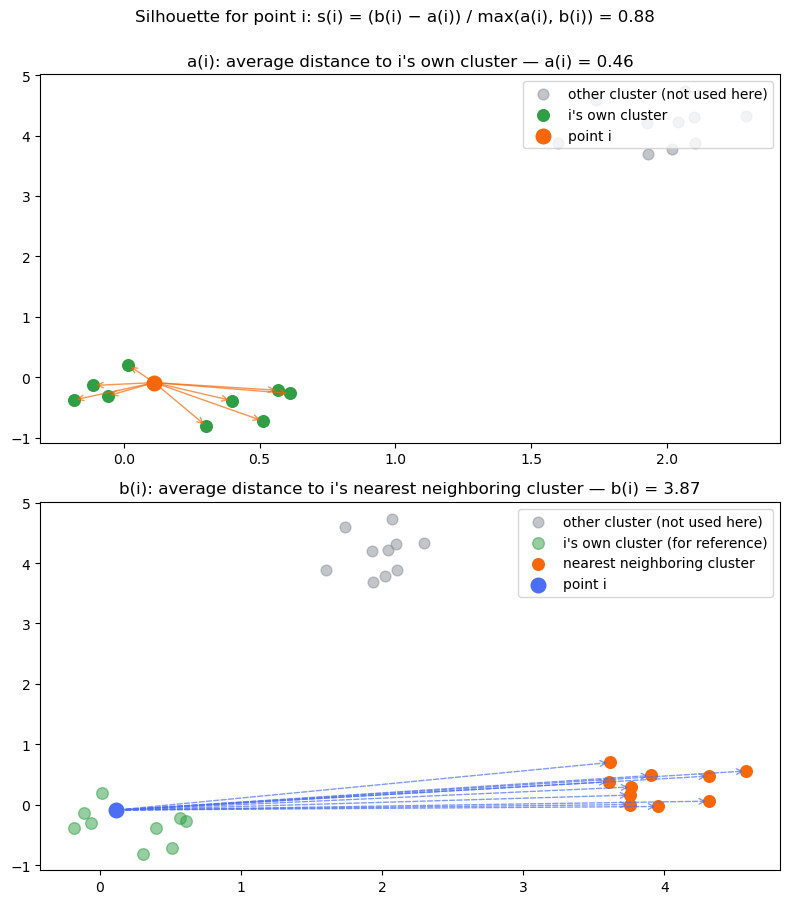

In [2]:
np.random.seed(1)
X_ex, y_ex = make_blobs(n_samples=[10, 10, 10], centers=[[0, 0], [4, 0.3], [2, 4]],
                         cluster_std=0.35, random_state=1)

own_cluster = 0
i_idx = np.where(y_ex == own_cluster)[0][0]
point_i = X_ex[i_idx]

centroids = np.array([X_ex[y_ex == c].mean(axis=0) for c in range(3)])
dist_to_centroids = np.linalg.norm(centroids - centroids[own_cluster], axis=1)
dist_to_centroids[own_cluster] = np.inf
nearest_cluster = int(dist_to_centroids.argmin())

own_others = X_ex[(y_ex == own_cluster)][~np.all(X_ex[y_ex == own_cluster] == point_i, axis=1)]
neighbor_points = X_ex[y_ex == nearest_cluster]
other_points = X_ex[(y_ex != own_cluster) & (y_ex != nearest_cluster)]

a_i = np.linalg.norm(own_others - point_i, axis=1).mean()
b_i = np.linalg.norm(neighbor_points - point_i, axis=1).mean()
s_i = (b_i - a_i) / max(a_i, b_i)

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# a(i): distance to own cluster
ax = axes[0]
ax.scatter(other_points[:, 0], other_points[:, 1], color=PALETTE['muted'], s=60, alpha=0.5,
           label='other cluster (not used here)')
ax.scatter(own_others[:, 0], own_others[:, 1], color=PALETTE['accent'], s=70,
           label="i's own cluster")
ax.scatter(*point_i, color=PALETTE['secondary'], s=110, zorder=5, label='point i')
for p in own_others:
    ax.annotate('', xy=p, xytext=point_i,
                arrowprops=dict(arrowstyle='->', color=PALETTE['secondary'], alpha=0.7))
ax.set_title(f'a(i): average distance to i\'s own cluster — a(i) = {a_i:.2f}')
ax.legend(loc='upper right')

# b(i): distance to nearest neighboring cluster
ax = axes[1]
ax.scatter(other_points[:, 0], other_points[:, 1], color=PALETTE['muted'], s=60, alpha=0.5,
           label='other cluster (not used here)')
ax.scatter(own_others[:, 0], own_others[:, 1], color=PALETTE['accent'], s=70, alpha=0.5,
           label="i's own cluster (for reference)")
ax.scatter(neighbor_points[:, 0], neighbor_points[:, 1], color=PALETTE['secondary'], s=70,
           label='nearest neighboring cluster')
ax.scatter(*point_i, color=PALETTE['primary'], s=110, zorder=5, label='point i')
for p in neighbor_points:
    ax.annotate('', xy=p, xytext=point_i,
                arrowprops=dict(arrowstyle='->', color=PALETTE['primary'], alpha=0.7, linestyle='dashed'))
ax.set_title(f"b(i): average distance to i's nearest neighboring cluster — b(i) = {b_i:.2f}")
ax.legend(loc='upper right')

fig.suptitle(f'Silhouette for point i: s(i) = (b(i) − a(i)) / max(a(i), b(i)) = {s_i:.2f}', y=1.0)
plt.tight_layout()
plt.show()


The gap statistic's "null" isn't abstract either, it's a real dataset you can draw and compare side by side. The chart below shows an actual clustered dataset next to a uniform random dataset built from the exact same bounding box, the same kind of reference the `gap_statistic` function below generates internally to test each K against.

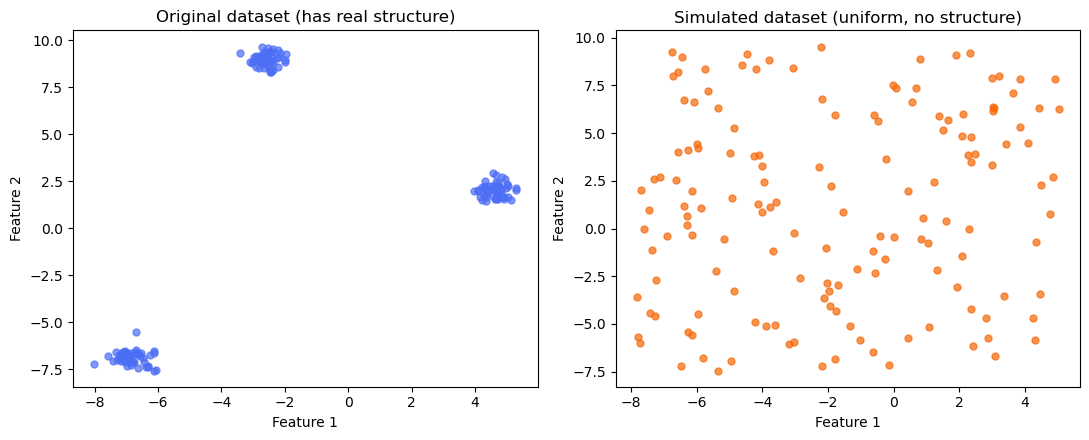

In [3]:
np.random.seed(42)
X_gap_demo, _ = make_blobs(n_samples=150, centers=3, cluster_std=0.35, random_state=42)

rng = np.random.default_rng(42)
gmin, gmax = X_gap_demo.min(axis=0), X_gap_demo.max(axis=0)
X_uniform_demo = rng.uniform(gmin, gmax, size=X_gap_demo.shape)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(X_gap_demo[:, 0], X_gap_demo[:, 1], color=PALETTE['primary'], s=25, alpha=0.7)
axes[0].set_title('Original dataset (has real structure)')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

axes[1].scatter(X_uniform_demo[:, 0], X_uniform_demo[:, 1], color=PALETTE['secondary'], s=25, alpha=0.7)
axes[1].set_title('Simulated dataset (uniform, no structure)')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()


---
## What's happening?

Three metrics, three different perspectives on the same question.

**WCSS elbow**: as K increases, inertia always decreases. The "elbow" is the kink where the rate of decrease slows. Subjective — eyeballing the elbow is inconsistent between analysts, which is why we need the other two metrics.

**Silhouette score**: asks "are my points in the right cluster?" The first diagram above makes its two ingredients concrete: a(i) is how far a point sits from the rest of its own cluster on average, and b(i) is how far it sits from the nearest other cluster. A confidently-assigned point has a small a(i) and a large b(i) — close to home, far from the neighbors — and that combination is exactly what pushes its silhouette score toward +1. Near 0 means on a cluster boundary, and negative means likely in the wrong cluster. The optimal K is where the average silhouette score, across every point, peaks.

**Gap statistic**: this one reuses a trick from hypothesis testing. In a hypothesis test, the "null" is always the boring, uninteresting case: no effect, no relationship, nothing going on. The second chart above shows exactly that null case for clustering: a uniform random dataset with no real groups at all, built from the same bounding box as your real data. A uniform scatter is the least predictable, most structureless thing you can generate: knowing where one point sits tells you nothing about where the next one is. Real clusters are the opposite — knowing one point's neighborhood tells you a lot about it. The gap statistic clusters your real data and a uniform random version of it at the same K, then compares the two: a *large* gap means your data looks nothing like random noise (real structure at that K); a *small* gap means your data looks about as clustered as pure chance (no real structure at that K, or all of it was already found at a smaller K). The best K is the smallest one that produces the largest gap — not automatically the biggest K on offer, since adding clusters can inflate the gap a little even when there's no new structure left to find. Chasing the single biggest gap regardless of K is a form of overfitting, the same instinct that says "keep clusters cheap unless the data insists otherwise."

These three methods often disagree. That disagreement is meaningful — it tells you the data's cluster structure is not perfectly clean.

> **Pause here — discuss as a class:** WCSS always shrinks and the gap statistic can keep climbing a little as K grows. So why not just keep adding clusters until every point is its own cluster?

In [4]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)
X_sc = StandardScaler().fit_transform(X)

def gap_statistic(X, k_range, B=10):
    gaps = []
    X_min, X_max = X.min(axis=0), X.max(axis=0)
    rng = np.random.default_rng(42)
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        km.fit(X)
        log_wcss = np.log(km.inertia_)
        ref_log_wcsss = []
        for _ in range(B):
            X_ref = rng.uniform(X_min, X_max, size=X.shape)
            km_ref = KMeans(n_clusters=k, n_init=5, random_state=42)
            km_ref.fit(X_ref)
            ref_log_wcsss.append(np.log(km_ref.inertia_))
        gaps.append(np.mean(ref_log_wcsss) - log_wcss)
    return gaps

k_range = list(range(2, 9))
wcss_vals = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_sc).inertia_ for k in k_range]
sil_vals  = [silhouette_score(X_sc, KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_sc))
             for k in k_range]
gap_vals  = gap_statistic(X_sc, k_range, B=10)

print('K  | WCSS    | Silhouette | Gap')
print('-' * 40)
for k, w, s, g in zip(k_range, wcss_vals, sil_vals, gap_vals):
    print(f'K={k} | {w:7.1f} | {s:.4f}     | {g:.4f}')

K  | WCSS    | Silhouette | Gap
----------------------------------------
K=2 |   310.5 | 0.5822     | -0.1055
K=3 |    62.9 | 0.7845     | 1.0386
K=4 |     6.4 | 0.8796     | 2.8788
K=5 |     5.7 | 0.7428     | 2.7970
K=6 |     5.1 | 0.6039     | 2.7330
K=7 |     4.5 | 0.4714     | 2.6759
K=8 |     4.0 | 0.3371     | 2.6500


---
## Real-world example: Three Metrics on the Same Dataset

Three evaluation charts for K from 2 to 8 on the same make_blobs data. Do they agree on the optimal K?

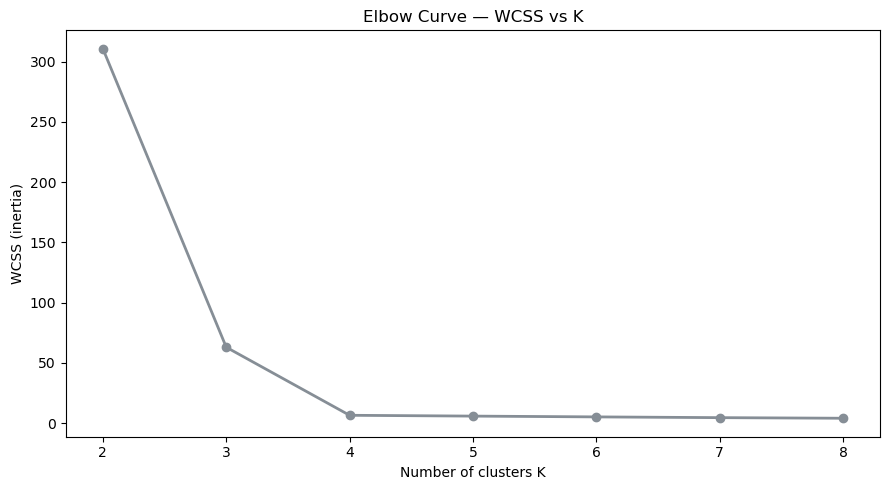

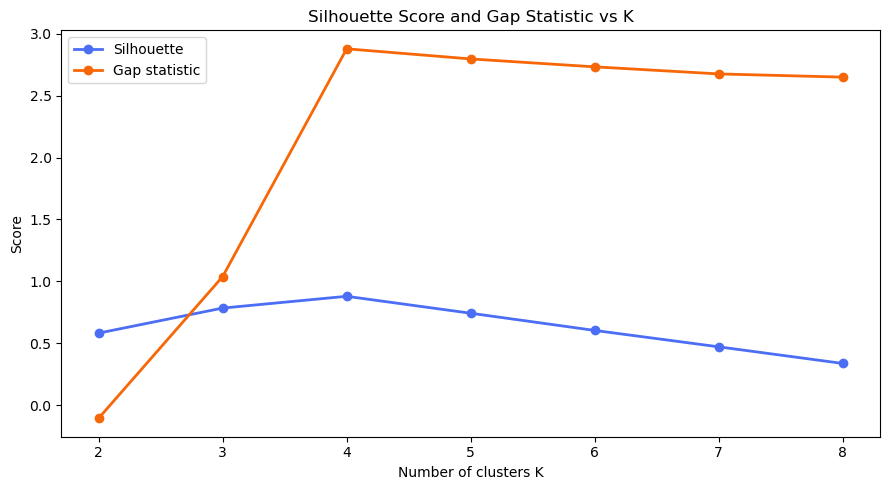

Best K by elbow (heuristic): 4
Best K by silhouette: 4
Best K by gap statistic: 4
True K: 4

Votes: Elbow=4, Gap=4, Silhouette=4 → agree on K=4


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_range, wcss_vals, marker='o', color=PALETTE['muted'], linewidth=2)
ax.set_title('Elbow Curve — WCSS vs K')
ax.set_xlabel('Number of clusters K')
ax.set_ylabel('WCSS (inertia)')
ax.set_xticks(k_range)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(9, 5))
ax2.plot(k_range, sil_vals, marker='o', color=PALETTE['primary'], linewidth=2, label='Silhouette')
ax2.plot(k_range, gap_vals, marker='o', color=PALETTE['secondary'], linewidth=2, label='Gap statistic')
ax2.set_title('Silhouette Score and Gap Statistic vs K')
ax2.set_xlabel('Number of clusters K')
ax2.set_ylabel('Score')
ax2.set_xticks(k_range)
ax2.legend()
plt.tight_layout()
plt.show()

# Elbow heuristic: the K right after the biggest relative drop-off in WCSS improvement
wcss_arr = np.array(wcss_vals)
decreases = -np.diff(wcss_arr)
decrease_ratios = decreases[1:] / decreases[:-1]
best_elbow = k_range[int(np.argmin(decrease_ratios)) + 1]
best_sil = k_range[sil_vals.index(max(sil_vals))]
best_gap = k_range[gap_vals.index(max(gap_vals))]

print(f'Best K by elbow (heuristic): {best_elbow}')
print(f'Best K by silhouette: {best_sil}')
print(f'Best K by gap statistic: {best_gap}')
print(f'True K: 4')
votes = {best_elbow: 0, best_sil: 0, best_gap: 0}
for k in (best_elbow, best_sil, best_gap):
    votes[k] += 1
agree_k = max(votes, key=votes.get)
print(f'\nVotes: Elbow={best_elbow}, Gap={best_gap}, Silhouette={best_sil}'
      + (f' → agree on K={agree_k}' if votes[agree_k] > 1 else ' → domain choice needed'))

---
## Key hyperparameters

This notebook covers metrics rather than a single sklearn estimator. Key sklearn functions:

**`sklearn.metrics.silhouette_score(X, labels)`**: returns the mean silhouette coefficient. Higher is better (range: -1 to 1).

**`sklearn.metrics.silhouette_samples(X, labels)`**: per-point silhouette coefficients for the silhouette plot.

**`sklearn.metrics.davies_bouldin_score(X, labels)`**: alternative metric — lower is better (ratio of within/between cluster spread).

**`sklearn.metrics.calinski_harabasz_score(X, labels)`**: another alternative — higher is better (ratio of between/within cluster variance).

---
## Strengths and weaknesses

| Metric | Strength | Weakness |
|--------|----------|----------|
| WCSS Elbow | Simple, fast, intuitive | Elbow is subjective; always decreases |
| Gap Statistic | Principled null comparison | Computationally expensive; reference distribution choice matters |
| Silhouette | Measures both cohesion and separation | Assumes convex clusters; O(n²) for large datasets |
| Davies-Bouldin | No parameter choice required | Less intuitive than silhouette |
| Calinski-Harabasz | Fast to compute | Biased toward convex clusters and higher K |

---
## When to use each metric

| Use when... | Preferred metric |
|-------------|-----------------|
| You want a quick first estimate | WCSS elbow |
| You want the most principled K choice | Gap statistic |
| You want to evaluate an existing clustering | Silhouette |
| K is already fixed; comparing two clustering results | Silhouette or Davies-Bouldin |
| Dataset is very large and silhouette is too slow | Calinski-Harabasz |

---
## Key takeaway

> **No single evaluation metric gives the definitive answer for clustering — use WCSS, gap statistic, and silhouette score together, then let domain knowledge make the final call.**

---
*Next up: 07_pca — where you compress many features into a few that capture most of the variance*